# Projected separation between the two galaxies in NGC 477

This notebook computes the projected angular separation between the two galaxies using the WCS of the HI data cube used in `Galaxy-preview.ipynb`.

The centers are the same pixel centers used there to isolate each galaxy:

- Galaxy 1: `(x, y) = (30, 32)`
- Galaxy 2: `(x, y) = (53, 23)`

The projected physical separation is computed with the small-angle relation:

`separation = angular_separation_rad * distance`

We use the NED mean redshift-independent distance shown in the data base, `D = 90.063 Mpc`, and also report the value using the NED Hubble distance, `D = 82.74 Mpc`, for comparison.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.io import fits
from astropy.wcs import WCS

In [2]:
# Data cube path used in Galaxy-preview.ipynb
data_dir = Path("/home/angeldavid/Desktop/Fedora/RESEARCH-INTERSHIPS/data_cubes/S0121+3848")
cube_path = data_dir / "S0116+4114_HIcube2_clean_smooth_image_4_cube.fits"

header = fits.getheader(cube_path)
data_cube = fits.getdata(cube_path)
wcs = WCS(header).celestial

print("Cube shape:", data_cube.shape)
print("Spatial pixel scale:", wcs.proj_plane_pixel_scales()[0].to(u.arcsec))

Cube shape: (71, 63, 75)
Spatial pixel scale: 6.0000012 arcsec


## Galaxy centers

These are the two centers used in `Galaxy-preview.ipynb` to make the circular masks for the two galaxies. FITS/WCS pixel coordinates below are zero-indexed, matching NumPy and Matplotlib image coordinates.

In [3]:
galaxy_centers_pix = {
    "Galaxy 1": (30, 32),
    "Galaxy 2": (53, 23),
}

galaxy_coords = {}

for name, (x, y) in galaxy_centers_pix.items():
    ra_deg, dec_deg = wcs.pixel_to_world_values(x, y)
    galaxy_coords[name] = SkyCoord(ra=ra_deg * u.deg, dec=dec_deg * u.deg, frame="icrs")
    print(f"{name}: x={x:5.1f}, y={y:5.1f}, RA={ra_deg:.8f} deg, Dec={dec_deg:.8f} deg")

Galaxy 1: x= 30.0, y= 32.0, RA=20.33738504 deg, Dec=40.48581992 deg
Galaxy 2: x= 53.0, y= 23.0, RA=20.28673372 deg, Dec=40.47136090 deg


## Angular and projected physical separation

In [4]:
coord_1 = galaxy_coords["Galaxy 1"]
coord_2 = galaxy_coords["Galaxy 2"]

angular_sep = coord_1.separation(coord_2)

# Distances from the NED screenshot.
ned_mean_distance_mpc = 90.063
ned_hubble_distance_mpc = 82.74

projected_sep_mean_mpc = angular_sep.to(u.rad).value * ned_mean_distance_mpc
projected_sep_hubble_mpc = angular_sep.to(u.rad).value * ned_hubble_distance_mpc

print(f"Angular separation: {angular_sep.deg:.8f} deg")
print(f"Angular separation: {angular_sep.arcmin:.6f} arcmin")
print(f"Angular separation: {angular_sep.arcsec:.6f} arcsec")
print()
print(f"Projected separation using D = {ned_mean_distance_mpc:.3f} Mpc: {projected_sep_mean_mpc:.6f} Mpc = {projected_sep_mean_mpc * 1000:.3f} kpc")
print(f"Projected separation using D = {ned_hubble_distance_mpc:.2f} Mpc: {projected_sep_hubble_mpc:.6f} Mpc = {projected_sep_hubble_mpc * 1000:.3f} kpc")

Angular separation: 0.04115166 deg
Angular separation: 2.469100 arcmin
Angular separation: 148.145984 arcsec

Projected separation using D = 90.063 Mpc: 0.064686 Mpc = 64.686 kpc
Projected separation using D = 82.74 Mpc: 0.059427 Mpc = 59.427 kpc


Expected result with the current centers:

- Angular separation: `148.146 arcsec` = `2.469 arcmin`
- Projected separation at `D = 90.063 Mpc`: `0.06469 Mpc` = `64.69 kpc`
- Projected separation at `D = 82.74 Mpc`: `0.05943 Mpc` = `59.43 kpc`

For the adopted NED mean distance, the projected separation is therefore approximately **64.7 kpc**.

## Visual check on the HI moment-0 map

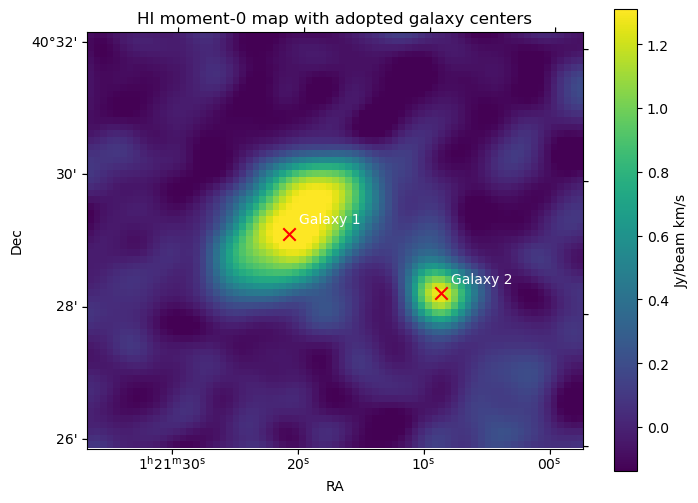

In [5]:
# Build a simple moment-0 image for a visual sanity check.
c_kms = 299792.458
f0_mhz = 1420.40575
freq_mhz = (header["CRVAL3"] + np.arange(header["NAXIS3"]) * header["CDELT3"]) / 1e6
vel_kms = c_kms * (freq_mhz - f0_mhz) / f0_mhz
dv_kms = np.abs(np.nanmedian(np.diff(vel_kms)))

mom0 = np.nansum(data_cube, axis=0) * dv_kms

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection=wcs)
im = ax.imshow(mom0, origin="lower", cmap="viridis", vmin=np.nanpercentile(mom0, 5), vmax=np.nanpercentile(mom0, 99))

for name, (x, y) in galaxy_centers_pix.items():
    ax.scatter(x, y, s=80, marker="x", color="red", transform=ax.get_transform("pixel"))
    ax.text(x + 1.5, y + 1.5, name, color="white", transform=ax.get_transform("pixel"))

ax.set_xlabel("RA")
ax.set_ylabel("Dec")
ax.set_title("HI moment-0 map with adopted galaxy centers")
fig.colorbar(im, ax=ax, label="Jy/beam km/s")
plt.show()